## Solución del problema mediante algoritmo de DPLL 
A continuación intentaremos encontrar un modelo para las reglas utilizando el algoritmo de DPLL

In [2]:
from logica import*   
from grafos import*

In [3]:
g=Grafos()

In [4]:
def filtro(dict_tseitin, regla): 
    h = inorder_to_tree(regla) 
    letras = h.letras()

    
    #Nos quedaremos solo con las letras válidas, en algunos algoritmos usamos auxiliares con unicoded mayores a 100, por eso nos quedaremos con las menores
    letras_validas = set()
    for l in letras:
        if ord(l) < 1000:   
            letras_validas.add(l)

    for letter in dict_tseitin.copy(): 
        if letter not in letras_validas: 
            del dict_tseitin[letter] 

    return dict_tseitin 

In [5]:
%time 
#REGLA 1
A1 = g.reglas[0]
ts1 = tseitin(A1)   
r1 = dpll(ts1, {}) 
I1 = filtro(r1[1], A1)


CPU times: total: 0 ns
Wall time: 6.44 μs


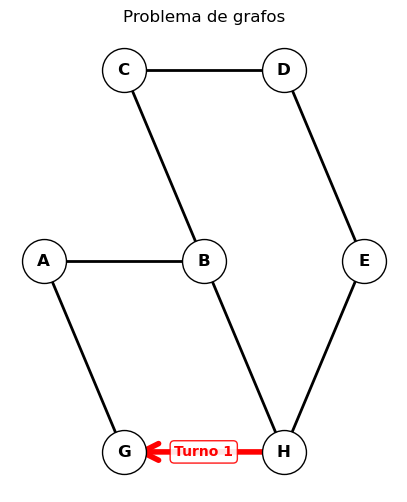

In [6]:
g.visualizar_grafo(I1)

In [ ]:
%time  
#REGLA 2
A2 = g.reglas[1] 
ts2 = tseitin(A2)   
r2 = dpll(ts2, {}) 
I2 = filtro(r2[1], A2) 


CPU times: total: 0 ns
Wall time: 9.3 μs


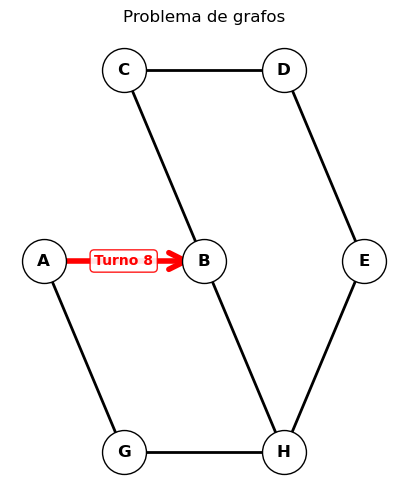

In [ ]:
g.visualizar_grafo(I2)

In [9]:
def regla3_1():
    formula_turnos = []

    for t in range(g.turnos):

        # 🔹 variables en el turno t
        vars_t = [g.To.ravel([recorrido, t]) for recorrido in g.recorridos]

        if not vars_t:
            continue

        # 🔹 construir OR tipo cebolla
        formula_turno = vars_t[0]
        for v in vars_t[1:]:
            formula_turno = "(" + formula_turno + "O" + v + ")"

        formula_turnos.append(formula_turno)

    # 🔹 unir todos los turnos con Y
    if not formula_turnos:
        return ""

    formula_final = formula_turnos[0]
    for f in formula_turnos[1:]:
        formula_final = "(" + formula_final + "Y" + f + ")"

    return formula_final

CPU times: total: 0 ns
Wall time: 6.2 μs


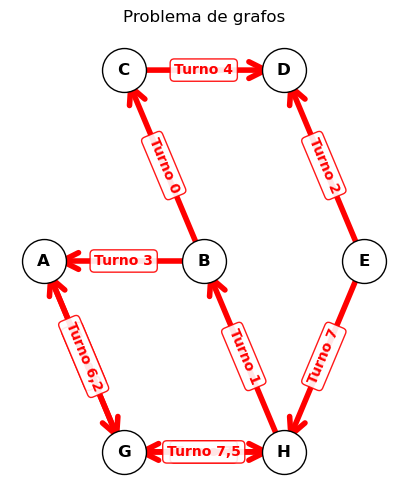

In [10]:
#Regla 3 
%time  
A3 = regla3_1()
ts3 = tseitin(A3)   
r3 = dpll(ts3, {}) 
I3 = filtro(r3[1], A3)  
g.visualizar_grafo(I3)


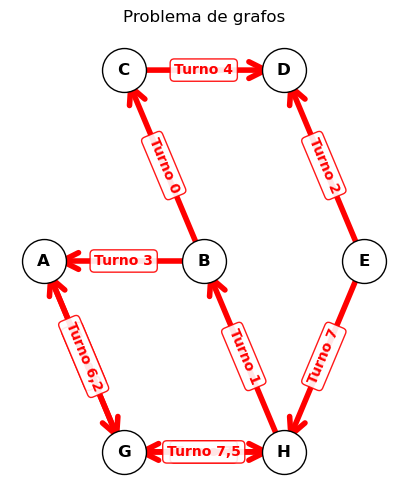

In [11]:
g.visualizar_grafo(I3)

In [12]:
#Regla 4
%time  

A4 = g.reglas[3] 
A4
#ts4 = tseitin(A4)   
#r4 = dpll(ts4, {}) 
#I4 = filtro(r4[1], A4)  

CPU times: total: 0 ns
Wall time: 7.39 μs


'(((((((((((((((((((((((Ā>((((((-(ĐOđ)Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű)))Y(Đ>((((((-(ĀOā)Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(Ġ>((((((-(ĀOā)Y-(ĐOđ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(İ>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(ŀ>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŐOő))Y-(ŠOš))Y-(ŰOű))))Y(Ő>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŠOš))Y-(ŰOű))))Y(Š>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŰOű))))Y(Ű>((((((-(ĀOā)Y-(ĐOđ))Y-(ĠOġ))Y-(İOı))Y-(ŀOŁ))Y-(ŐOő))Y-(ŠOš))))Y((((((((ā>((((((-(đOĐ)Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ)))Y(đ>((((((-(āOĀ)Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(ġ>((((((-(āOĀ)Y-(đOĐ))Y-(ıOİ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(ı>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ŁOŀ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(Ł>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ıOİ))Y-(őOŐ))Y-(šOŠ))Y-(űOŰ))))Y(ő>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y-(šOŠ))Y-(űOŰ))))Y(š>((((((-(āOĀ)Y-(đOĐ))Y-(ġOĠ))Y-(ıOİ))Y-(ŁOŀ))Y

3. Cada arista del grafo debe ser transitada al menos una vez. 
$$\bigwedge_{(i,j) \in A} \bigwedge_{t \in T} \left( To(i,j,t) \implies \bigwedge_{l \neq t} (\neg To(i,j,l) \wedge \neg To(j,i,l)) \right)$$
4. Ninguna arista puede ser recorrida más de una vez durante la secuencia.   $$\bigwedge_{(i,j) \in A} \bigwedge_{t \in T} \left( To(i,j,t) \implies \bigwedge_{l \neq t} (\neg To(i,j,l) \wedge \neg To(j,i,l)) \right)$$

regla 4 no corrió después de 236 minutos

In [13]:
def regla4_1(): 
    '''Explicación de este algoritmo: 
    Queremos que ninguna arista puede ser recorrida más de una vez durante la secuencia.
    En otras palabras, que dados x1 = (i,j,t) O (j,i,t) y x2 = (i,j,r) O (j,i,r), con r!=t 
    esté prohibido que x1=True Y x2=True 
    esto lo podríamos hacer con (-x1O-x2) (Formalmente la regla es más grande pero esta simplificación basta para entender), sin embargo probamos empiricamente de que 
    hacer esto y llevar la misma lógica de la fórmula formal conlleva el uso de muchos ciclos. Lo cual incrementa la complejidad del algoritmo notablemnete. 

    Por otro lado, existe un acercamiento que mejora notablemente el tiempo de complejidad. La idea es introducir una variable auxiliar s1 que se relacione con los dos valores. 
    De esa manera podríamos reescribir la cláusula disyuntiva (-x1O-x2) con (-x1 O s1) Y (-x2 O -s1). 
    Observe que esta reescritura prohibe que x1= True Y x2= True    
    
    '''

    formula_lista_aristas = []
    contador_aux = 1000  

    for (i, j) in g.recorridos:
        #Vars_arista = lista de todos los posibles recorridos de la lista en unicode
        vars_arista = []
        for t in range(g.turnos):
            vars_arista.append(g.To.ravel([(i, j), t]))
            vars_arista.append(g.To.ravel([(j, i), t]))

        n = len(vars_arista)

        #Vamos a crear variables auxiliares que recordarán si un recorrido ya se hace. 
        auxiliar = []
        for i in range(n - 1):
            auxiliar.append(chr(contador_aux))
            #Vamos poniendo letras de unicode
            contador_aux += 1

        formula_actual = ""
        inicial = True
        
        
        #Empecemos armando nuestras clausulas: (-x1 O s1) es nuestra clausula inicial
        c = "(-" + vars_arista[0] + "O" + auxiliar[0] + ")"
        formula_actual = c
        inicial = False

        #Armaremos el resto de clausulas
        for k in range(1, n - 1): 
            #Vamos a guardar en xk el atomo que estamos
            xk = vars_arista[k]

            c1 = "(-" + xk + "O" + auxiliar[k] + ")"
            c2 = "(-" + auxiliar[k-1] + "O" + auxiliar[k] + ")"
            c3 = "(-" + xk + "O-" + auxiliar[k-1] + ")"
            #Esto nos garantiza de que ningun x1 == x2, es decir que no se de un movimiento en una arista en más de un turno

            #Iremos añadiendo estas condiciones mediante una ytoria. Este extra for no es tan dañino pues solo tiene 3 elementos
            for c in [c1, c2, c3]:
                formula_actual = "(" + formula_actual + "Y" + c + ")"

        #Construimos la ultima condición  para cerrar 
        c_last = "(-" + vars_arista[-1] + "O-" + auxiliar[-1] + ")"
        formula_actual = "(" + formula_actual + "Y" + c_last + ")"
        formula_lista_aristas.append(formula_actual)

    # Ahora vamos a unir todo de una forma más organizada
    formula_final = ""
    inicial_final = True

    for f in formula_lista_aristas:
        if inicial_final:
            formula_final = f
            inicial_final = False
        else:
            #Añadimos todo mediante una Ytoria.
            formula_final = "(" + formula_final + "Y" + f + ")"

    return formula_final

In [14]:
%time
A4_1 = regla4_1() 
ts4 = tseitin(A4_1)  
r4 = dpll(ts4, {}) 
I4 = filtro(r4[1], A4_1)  

CPU times: total: 0 ns
Wall time: 6.2 μs


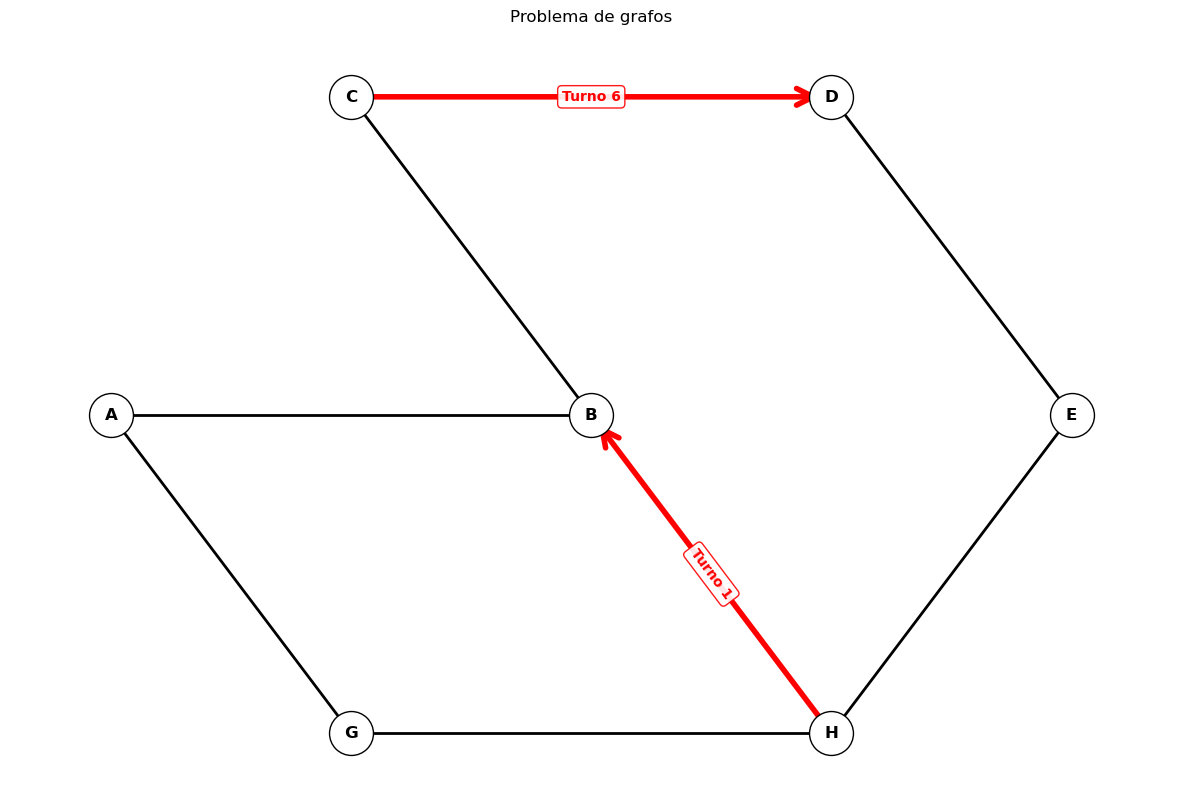

In [15]:
g.visualizar_grafo(I4,custom_size=(15,10) )

In [16]:
def regla5():
    formula_lista = []

    # 🔹 precomputar salidas
    salidas = {}
    for (a,b) in g.recorridos:
        if a not in salidas:
            salidas[a] = []
        salidas[a].append((a,b))

    for t in range(1, g.turnos):
        for (i, j) in g.recorridos:

            salidas_desde_j = salidas.get(j, [])

            # 🔹 construir consecuente más rápido
            if not salidas_desde_j:
                continue

            formula_consecuente = g.To.ravel([salidas_desde_j[0], t])

            for (a,b) in salidas_desde_j[1:]:
                formula_consecuente = "(" + formula_consecuente + "O" + g.To.ravel([(a,b), t]) + ")"

            # 🔹 antecedente
            formula_antecedente = g.To.ravel([(i, j), t - 1])

            # 🔹 implicación
            formula_lista.append("(" + formula_antecedente + ">" + formula_consecuente + ")")

    # 🔹 cebolla final
    if not formula_lista:
        return ""

    formula = formula_lista[0]
    for f in formula_lista[1:]:
        formula = "(" + formula + "Y" + f + ")"

    return formula

In [17]:
%time
A5 = regla5() 
ts5 = tseitin(A5)  
r5 = dpll(ts5, {})  
I = r5[1]
I5 = filtro(r5[1], A5)  

CPU times: total: 0 ns
Wall time: 7.39 μs


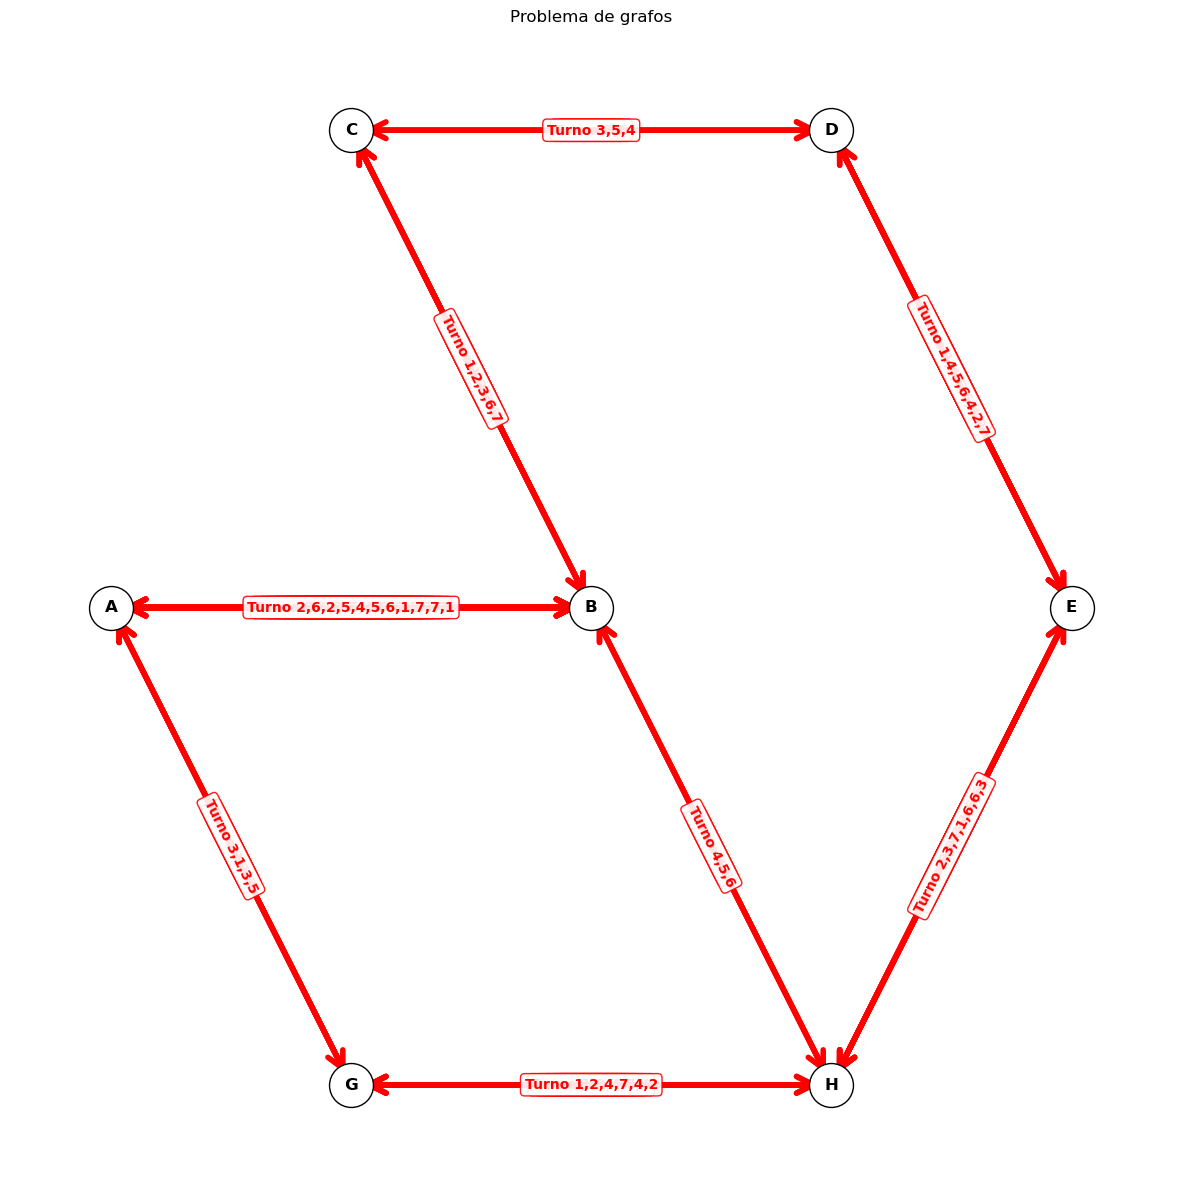

In [18]:
g.visualizar_grafo(I5, custom_size=(15,15))

In [ ]:
%time
reglas = Ytoria([g.reglas[0], g.reglas[1],A3, A4_1, A5])
A = reglas  
ts = tseitin(A) 
r = dpll(ts,{})
I = filtro(r[1], A) 
g.visualizar_grafo(I)

CPU times: total: 0 ns
Wall time: 9.3 μs
